# Workshop Bias di Genere — Modelli e Casi Sperimentali

**Dataset**: NHANES 2013-2014 (National Health and Nutrition Examination Survey, USA)
**Obiettivo del notebook**: mostrare con tre esperimenti diversi *come* il bias di genere può entrare in un modello di intelligenza artificiale clinica, anche quando il modello in sé è "neutro".

> Il workshop nasce per un pubblico misto: medici, ricercatori, e persone semplicemente interessate al tema. Per questo motivo **ogni cella di codice è preceduta da una spiegazione in italiano**: chi vuole può limitarsi a leggere il testo e guardare i grafici, e capire comunque l'esperimento.

---

## Indice

0. **Preparazione dell'ambiente** — installazione librerie, caricamento dati
1. **Pre-flight: pulizia condivisa del dataset** — gli step preliminari che tutti e tre i casi useranno
2. **Caso 1 — *Bias di numerosità del genere*** — cosa succede se il training set ha meno donne degli uomini?
3. **Caso 2 — *Two Clinics*** — cosa succede se uomini e donne arrivano da due "cliniche" diverse?
4. **Caso 3 — *Modelli sex-specific*** — esiste un modo "giusto" di trattare il sesso come variabile?

---


## 0 · Preparazione dell'ambiente

Prima di tutto carichiamo gli strumenti che ci serviranno: librerie per leggere tabelle (`pandas`), per fare grafici (`matplotlib`, `seaborn`), per costruire modelli (`scikit-learn`, `xgboost`).

> **Per chi non programma**: una "libreria" è una scatola di funzioni già pronte scritte da altri. Importarla significa "ho a disposizione questi strumenti".


In [1]:
# Se siete su Google Colab, decommentate la riga seguente per montare il vostro Drive
# dove avete caricato il dataset NHANES.
# from google.colab import drive; drive.mount('/content/drive')

# --- Configurazione percorsi ----------------------------------------------
# Modificate DATA_PATH se il file si trova altrove (es. su Drive).
DATA_PATH = 'NHANES_2013_2014_CSV/NHANES_2013_2014_CSV/NHANES_2013_2014_master.csv'
OUTPUT_DIR = 'archive'   # qui salveremo i risultati intermedi
SEED = 42                # garantisce risultati riproducibili
N_BOOTSTRAP = 100        # numero di ripetizioni bootstrap (vedi sezione 1.7 per la spiegazione)


In [2]:
# --- Librerie standard ----------------------------------------------------
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
np.random.seed(SEED)

# Creiamo le cartelle di output (silenziose se gia' esistono)
os.makedirs(f'{OUTPUT_DIR}/preflight', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/case1', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/case2', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/case3', exist_ok=True)

print('Ambiente pronto. Seed fissato a', SEED)


Ambiente pronto. Seed fissato a 42


---

## 1 · Pre-flight — Pulizia condivisa del dataset

Prima di tirare su qualsiasi modello, dobbiamo preparare il dato. Questa è una fase noiosa ma **fondamentale**: se la salti o la sbagli, **tutti i risultati successivi sono inquinati** e nessuno se ne accorge subito.

Faremo sei passi, nell'ordine:

| Step | Cosa facciamo | Perché |
|------|---------------|--------|
| 1.1 | Carichiamo il dataset | Vediamo cosa c'è dentro |
| 1.2 | Teniamo solo gli adulti (≥18 anni) | I target clinici di cui parleremo non hanno senso sui bambini |
| 1.3 | Sistemiamo i codici binari di NHANES | Senza questo passo le prevalenze sembrano >100% e i segni si invertono |
| 1.4 | Rimuoviamo le variabili "100% mancanti in un sesso" | Altrimenti il modello impara il sesso dai NaN, non dai dati |
| 1.5 | Costruiamo un **test set fisso** (750 uomini + 750 donne) | È il "metro" condiviso: tutti e tre i casi lo useranno per valutarsi |
| 1.6 | Definiamo il **pool di training** | Tutto il resto resta disponibile per allenare i modelli dei tre casi |

> **Una nota importante che ricorrerà spesso**: imputazione dei valori mancanti e standardizzazione delle feature **non** vanno fatte qui. Vanno fatte *dentro* ogni esperimento, separatamente per training e test, altrimenti il dato "trapassa" tra fold e i risultati sono troppo ottimistici. Questo si chiama *data leakage*.


### 1.1 · Caricamento del dataset

Il file `NHANES_2013_2014_master.csv` è la versione consolidata della survey americana NHANES per gli anni 2013-2014. Contiene una riga per ogni partecipante e una colonna per ogni variabile rilevata: dati anagrafici, esami di laboratorio, questionari, misure fisiche.


In [3]:
master = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dimensioni del dataset originale: {master.shape[0]} righe x {master.shape[1]} colonne')
print(f'Cioe\': {master.shape[0]} persone osservate, {master.shape[1]} variabili registrate per ognuna.')


Dimensioni del dataset originale: 10175 righe x 1812 colonne
Cioe': 10175 persone osservate, 1812 variabili registrate per ognuna.


In [4]:
# Diamo un'occhiata alle prime righe e ad alcune colonne familiari
master[['age_years', 'gender', 'bmi', 'bp_systolic_1']].head(8)


,age_years,gender,bmi,bp_systolic_1
0,69,1,26.7,122.0
1,54,1,28.6,156.0
2,72,1,28.9,140.0
3,9,1,17.1,108.0
4,73,2,19.7,136.0
5,56,1,41.7,160.0
6,0,1,NaN,NaN
7,61,2,35.7,118.0


> **Codifica del sesso in NHANES**: la colonna `gender` vale `1` per gli uomini e `2` per le donne. Lo terremo a mente per tutto il notebook.


### 1.2 · Solo adulti (età ≥ 18 anni)

I target clinici che useremo (diabete, artrite, ipertensione) sono malattie dell'adulto. Includere bambini e adolescenti complicherebbe la lettura senza aggiungere nulla.


In [5]:
adult = master[master['age_years'] >= 18].copy()
print(f'Adulti (>=18 anni): {len(adult)} su {len(master)} totali ({len(adult)/len(master)*100:.1f}%)')
print()
print('Distribuzione per sesso fra gli adulti:')
print(adult['gender'].value_counts().rename({1: 'Uomini (M)', 2: 'Donne (F)'}))


Adulti (>=18 anni): 6113 su 10175 totali (60.1%)

Distribuzione per sesso fra gli adulti:
gender
Donne (F)     3197
Uomini (M)    2916
Name: count, dtype: int64


### 1.3 · Sistemiamo i codici binari di NHANES

In NHANES molte domande sì/no sono codificate così:

| Codice | Significato |
|--------|-------------|
| `1` | Sì |
| `2` | No |
| `3` | "Borderline / non so" |
| `7` | "Rifiuto di rispondere" |
| `9` | "Non lo so" |

Se trattiamo questi numeri come se fossero quantità reali, succedono **disastri**: per esempio, se calcoliamo "quante persone hanno il diabete" sommando direttamente questa colonna, otteniamo numeri assurdi perché un "no" vale `2`, non `0`.

La regola corretta è: **`1 → 1` (sì), `2 → 0` (no), `3/7/9 → NaN` (informazione mancante)**.

Applichiamo questa regola a tutte le variabili binarie del questionario di interesse: diabete (`diab_*`), condizioni mediche (`mc_*`), e domande sulla pressione e colesterolo (`bp_told_*`).


In [6]:
def recode_nhanes_binary(series):
    """1->1, 2->0, 3/7/9->NaN (codifica standard binaria NHANES)."""
    return series.map({1: 1, 2: 0}).where(series.isin([1, 2]))


binary_prefixes = ('diab_', 'mc_', 'bp_told_')
binary_cols = [c for c in adult.columns if c.startswith(binary_prefixes)]
print(f'Colonne binarie NHANES da ricodificare: {len(binary_cols)}')

# Mostriamo prima/dopo su un esempio per far vedere il problema
target_demo = 'diab_doctor_told_diabetes'
print(f'\nESEMPIO su `{target_demo}`:')
print('  Distribuzione GREZZA (sbagliata): ',
      dict(adult[target_demo].value_counts(dropna=False).head()))
adult[binary_cols] = adult[binary_cols].apply(recode_nhanes_binary)
print('  Distribuzione DOPO ricodifica  : ',
      dict(adult[target_demo].value_counts(dropna=False).head()))
print(f'  Prevalenza vera del diabete fra gli adulti: {adult[target_demo].mean()*100:.1f}%')


Colonne binarie NHANES da ricodificare: 148

ESEMPIO su `diab_doctor_told_diabetes`:
  Distribuzione GREZZA (sbagliata):  {2.0: 5208, 1.0: 726, 3.0: 176, 9.0: 3}
  Distribuzione DOPO ricodifica  :  {0.0: 5208, 1.0: 726, nan: 179}
  Prevalenza vera del diabete fra gli adulti: 12.2%


> **Cosa abbiamo guadagnato**: ora la prevalenza del diabete è ~12% (un valore epidemiologicamente sensato), e non un numero sballato come avremmo ottenuto sommando i codici grezzi.


### 1.4 · Rimuoviamo le variabili "100% mancanti in un sesso"

In NHANES alcune domande sono fatte solo agli uomini (es. salute della prostata) o solo alle donne (es. età della prima mestruazione, gravidanze). Per il sesso non interrogato, il valore è **sempre mancante (`NaN`)**.

Se le lasciamo nel dataset, succede una cosa subdola: anche un modello molto stupido può imparare il sesso **semplicemente guardando se quei valori sono mancanti o no**. Il sesso "rientra dalla finestra" via missingness, e tutti i nostri esperimenti sul bias diventano falsati.

Soluzione: rimuoviamo qualunque colonna che sia mancante in **almeno il 99%** delle osservazioni in **uno dei due sessi**.


In [7]:
miss_M = adult[adult['gender'] == 1].isna().mean()
miss_F = adult[adult['gender'] == 2].isna().mean()

structural_missing = miss_M[(miss_M >= 0.99) | (miss_F >= 0.99)].index.tolist()
# Non vogliamo eliminare 'gender' stessa per sicurezza (non e' missing-by-sex)
structural_missing = [c for c in structural_missing if c != 'gender']

print(f'Colonne da rimuovere: {len(structural_missing)}')
print('\nEsempio di colonne tipiche rimosse:')
example = pd.DataFrame({
    'colonna': structural_missing[:8],
    'missing nei M (%)': [f'{miss_M[c]*100:.1f}' for c in structural_missing[:8]],
    'missing nelle F (%)': [f'{miss_F[c]*100:.1f}' for c in structural_missing[:8]],
})
print(example.to_string(index=False))


Colonne da rimuovere: 534

Esempio di colonne tipiche rimosse:
                 colonna missing nei M (%) missing nelle F (%)
    age_months_screening             100.0               100.0
        pregnancy_status             100.0                59.1
 bp_child_heart_rate_30s             100.0               100.0
     recumbent_length_cm             100.0               100.0
recumbent_length_comment             100.0               100.0
            head_circ_cm             100.0               100.0
       head_circ_comment             100.0               100.0
        cs_smell_current             100.0                69.4


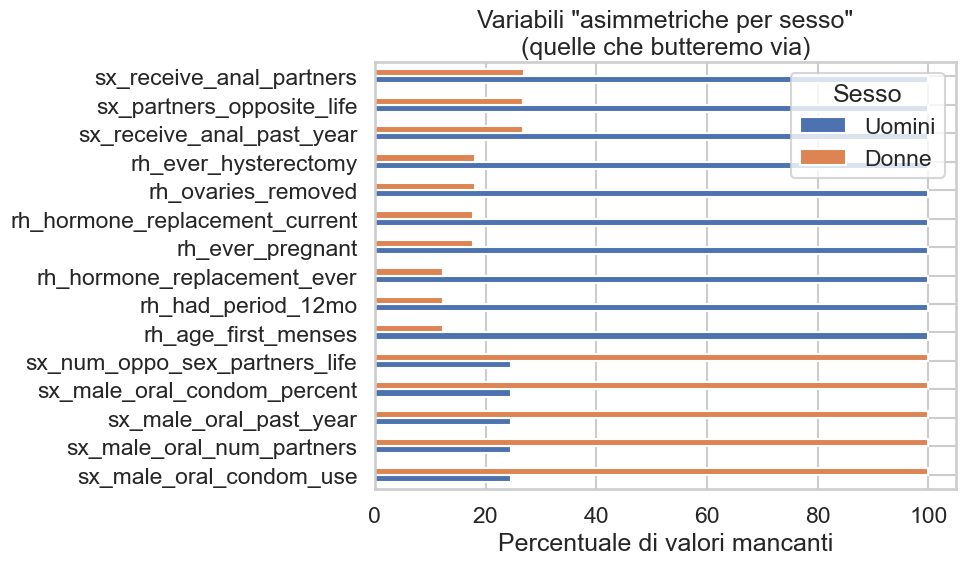

In [8]:
# Visualizziamo il pattern: la slide e' molto piu' chiara di mille parole
top_drop = (miss_M - miss_F).abs().sort_values(ascending=False).head(15).index
plot_df = pd.DataFrame({
    'Uomini': miss_M[top_drop] * 100,
    'Donne': miss_F[top_drop] * 100,
}).sort_values('Uomini', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Percentuale di valori mancanti')
ax.set_title('Variabili "asimmetriche per sesso"\n(quelle che butteremo via)')
ax.legend(title='Sesso')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preflight/missing_by_sex_top15.png', dpi=120)
plt.show()


> **Come si legge il grafico**: ogni barra è una variabile. La barra blu mostra quanti maschi non hanno quel valore, quella arancione quante femmine. Una barra blu lunga 100% significa "questa domanda non è mai stata fatta agli uomini" — quindi il solo fatto che il valore esista già rivela il sesso.


In [9]:
adult_clean = adult.drop(columns=structural_missing)
print(f'Dataset dopo la pulizia: {adult_clean.shape[0]} righe x {adult_clean.shape[1]} colonne')
print(f'(prima erano {adult.shape[1]} colonne, ne abbiamo tolte {len(structural_missing)})')


Dataset dopo la pulizia: 6113 righe x 1278 colonne
(prima erano 1812 colonne, ne abbiamo tolte 534)


### 1.5 · Costruiamo il test set fisso

Per confrontare in modo onesto i tre casi del workshop, ci serve **un unico metro di valutazione**: un campione di pazienti che **non verrà mai usato per allenare nessun modello**. È il nostro "esame finale".

Lo costruiamo con queste regole:
- **1500 persone in totale**, perfettamente bilanciato fra i sessi: **750 uomini + 750 donne**
- estratto a caso, ma con un seed fisso (`42`) per garantire **riproducibilità**: chiunque rilancerà questo notebook avrà *esattamente* lo stesso test set
- una volta costruito, **non lo tocchiamo più** fino alla valutazione

> **Perché bilanciato 50/50?** Perché vogliamo dare al modello la stessa "chance" di essere bravo sui due sessi. Se il test fosse 90% maschi, una metrica globale come l'accuracy direbbe poco sulla performance per le donne.


In [10]:
rng = np.random.default_rng(SEED)

def stratified_sample(df, stratum_col, n_per_stratum, rng):
    parts = []
    for s, g in df.groupby(stratum_col):
        idx = rng.choice(g.index, size=n_per_stratum, replace=False)
        parts.append(df.loc[idx])
    return pd.concat(parts).sort_index()

test_fixed = stratified_sample(adult_clean, 'gender', n_per_stratum=750, rng=rng)
pool_train = adult_clean.drop(index=test_fixed.index)

print(f'Test set fisso: {len(test_fixed)} persone ({(test_fixed["gender"]==1).sum()} M + {(test_fixed["gender"]==2).sum()} F)')
print(f'Pool di training: {len(pool_train)} persone ({(pool_train["gender"]==1).sum()} M + {(pool_train["gender"]==2).sum()} F)')


Test set fisso: 1500 persone (750 M + 750 F)
Pool di training: 4613 persone (2166 M + 2447 F)


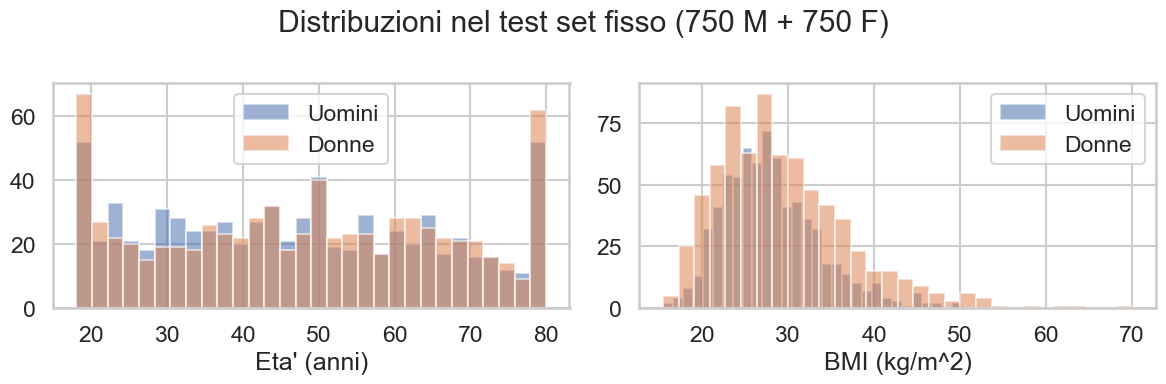

In [11]:
# Verifica veloce: eta' e BMI nel test set sono "ragionevoli", non strani
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['age_years', 'bmi'], ['Eta\' (anni)', 'BMI (kg/m^2)']):
    for g, lab, c in [(1, 'Uomini', '#4C72B0'), (2, 'Donne', '#DD8452')]:
        ax.hist(test_fixed.loc[test_fixed['gender']==g, col].dropna(),
                bins=30, alpha=0.55, label=lab, color=c)
    ax.set_xlabel(title); ax.legend()
fig.suptitle('Distribuzioni nel test set fisso (750 M + 750 F)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preflight/test_set_distributions.png', dpi=120)
plt.show()


### 1.6 · Salviamo i dati puliti

Salviamo il pool di training, il test fisso e un piccolo log con i passaggi e le numerosità. Da qui in poi, i tre casi caricheranno questi file e non rifaranno la pulizia.


In [12]:
adult_clean.to_csv(f'{OUTPUT_DIR}/preflight/adult_clean.csv', index=False)
pool_train.to_csv(f'{OUTPUT_DIR}/preflight/pool_train.csv', index=False)
test_fixed.to_csv(f'{OUTPUT_DIR}/preflight/test_fixed.csv', index=False)

log = {
    'seed': SEED,
    'n_master': int(master.shape[0]),
    'n_cols_master': int(master.shape[1]),
    'n_adults': int(adult.shape[0]),
    'n_cols_after_drop_sex_missing': int(adult_clean.shape[1]),
    'n_dropped_sex_missing': len(structural_missing),
    'n_pool_train': int(pool_train.shape[0]),
    'n_test_fixed': int(test_fixed.shape[0]),
    'test_male': int((test_fixed['gender'] == 1).sum()),
    'test_female': int((test_fixed['gender'] == 2).sum()),
}
with open(f'{OUTPUT_DIR}/preflight/preflight_log.json', 'w') as f:
    json.dump(log, f, indent=2)

pd.Series(structural_missing, name='dropped_column').to_csv(
    f'{OUTPUT_DIR}/preflight/columns_dropped_sex_missing.csv', index=False)

print('Pre-flight completato. File salvati in:', f'{OUTPUT_DIR}/preflight/')
print()
print(json.dumps(log, indent=2))


Pre-flight completato. File salvati in: archive/preflight/

{
  "seed": 42,
  "n_master": 10175,
  "n_cols_master": 1812,
  "n_adults": 6113,
  "n_cols_after_drop_sex_missing": 1278,
  "n_dropped_sex_missing": 534,
  "n_pool_train": 4613,
  "n_test_fixed": 1500,
  "test_male": 750,
  "test_female": 750
}


**Riepilogo del pre-flight**

Da qui in poi, in ogni caso del workshop:
- partiamo dal **pool di training** (≈4.600 persone, leggermente sbilanciato verso le donne, com'è la realtà adulta NHANES)
- valutiamo sempre sul **test fisso** da 1.500 persone (750 M + 750 F)
- l'imputazione dei valori mancanti e la standardizzazione le facciamo **dentro** ogni esperimento, non qui

Ora siamo pronti per il primo caso.

---


---

## 1.7 · Una pausa: cos'è il "bootstrap" e perché lo useremo ovunque

Tra poco vedrete spuntare ovunque la parola **bootstrap**. Vale la pena spiegarla una volta per tutte, perché è il modo in cui sapremo se i risultati che otterremo sono *veri* o sono semplice rumore.

**L'idea in una frase**: invece di addestrare il modello una volta sola, lo addestriamo **molte volte** (qui 100), ogni volta con un campione di training leggermente diverso estratto dallo stesso pool. Poi guardiamo come *ballano* i risultati.

**Un'analogia**: vi consegnano una moneta e vi chiedono se è truccata. La lanciate **una sola volta** e viene testa: cosa concludete? Niente — è successo per caso. La lanciate **100 volte** e viene testa 50 volte: ok, è normale. Ma se viene testa 80 volte, *adesso* potete dire con sicurezza che è truccata. Le **100 ripetizioni** vi danno un'idea di **quanto fidarvi della stima**.

**Cosa otteniamo dal bootstrap nel nostro caso**:

| Senza bootstrap | Con bootstrap (100 ripetizioni) |
|-----------------|----------------------------------|
| "AUROC sulle donne = 0.89" | "AUROC sulle donne = 0.89, intervallo [0.87, 0.91]" |
| Non so se rifittando otterrei 0.85 o 0.93 | So che il valore "vero" è dentro quella finestra al 95% |
| Non posso confrontare due numeri in modo onesto | Se due intervalli **non si toccano**, posso dire che la differenza è reale |

> Quando nei prossimi grafici vedrete "bande" attorno a una curva, o "barre di errore" attorno a una colonna, sono gli **intervalli di confidenza al 95%** prodotti dal bootstrap: il "respiro" della stima.

Tutto questo costa tempo (ogni esperimento si moltiplica per 100), ma è quello che separa una conclusione affrettata da una conclusione difendibile.

---


## 2 · Caso 1 — Bias di numerosità del genere

> **La domanda di ricerca**
> *A parità di tutto il resto, il solo fatto di cambiare il rapporto donne/uomini nel training set sposta in modo misurabile le predizioni del modello?*

È l'esperimento più semplice del workshop, ed è una **palestra** per quelli che vengono dopo. Non manipoliamo niente di sottile: cambiamo solo **quante donne** mettiamo nel training, lasciando intatto tutto il resto.

### Gli scenari

Costruiamo quattro versioni del training set, sempre con **la stessa quantità totale di dati (3.000 persone)**, ma con rapporti F:M progressivamente sbilanciati:

| Scenario | Donne | Uomini | Quota donne |
|----------|-------|--------|-------------|
| **S0** | 1500 | 1500 | 50% (baseline equilibrata) |
| **S1** |  900 | 2100 | 30% |
| **S2** |  450 | 2550 | 15% |
| **S3** |  150 | 2850 |  5% |

> **Perché tenere fisso il totale a 3000?** Per non mescolare due effetti diversi: "ho meno donne" e "ho meno dati in totale". Se fissiamo la quantità totale, l'unica cosa che cambia è il **rapporto**.

Tutti e quattro gli scenari verranno valutati **sullo stesso test fisso** (750 M + 750 F) costruito nel pre-flight.


In [13]:
# --- Configurazione scenari del Caso 1 -----------------------------------
SCENARIOS = {
    'S0_50-50': dict(n_F=1500, n_M=1500),
    'S1_30-70': dict(n_F= 900, n_M=2100),
    'S2_15-85': dict(n_F= 450, n_M=2550),
    'S3_5-95':  dict(n_F= 150, n_M=2850),
}

def make_scenario(pool, n_F, n_M, rng):
    """Estrae un training set con i numeri richiesti di F e M dal pool.

    Usa campionamento *con sostituzione* (bootstrap): permette di chiedere piu' unita'
    di quante ne abbia il pool e introduce variabilita' fra le ripetizioni.
    """
    pool_M = pool[pool['gender'] == 1]
    pool_F = pool[pool['gender'] == 2]
    if len(pool_M) == 0 or len(pool_F) == 0:
        raise ValueError('Pool vuoto in uno dei due sessi: controlla i filtri.')
    idx_M = rng.choice(pool_M.index, size=n_M, replace=True)
    idx_F = rng.choice(pool_F.index, size=n_F, replace=True)
    return pool.loc[list(idx_M) + list(idx_F)].sample(frac=1, random_state=int(rng.integers(1e9)))

# Verifica veloce che il pool abbia abbastanza persone (deve avere >=2850 M e >=1500 F)
print('Persone disponibili nel pool:',
      f'M={ (pool_train["gender"]==1).sum() },',
      f'F={ (pool_train["gender"]==2).sum() }')
print('Massimo richiesto da S3: M=2850, da S0: F=1500. Capienza OK.')


Persone disponibili nel pool: M=2166, F=2447
Massimo richiesto da S3: M=2850, da S0: F=1500. Capienza OK.


---

### 2A · Opzione 1A — Regressione lineare sulla pressione sistolica

> **L'esperimento**
> Predire la **pressione arteriosa sistolica** (`bp_systolic_1`, in mmHg) usando solo due variabili: il **BMI** e l'**età**. Confrontare cosa cambia nei coefficienti del modello al variare degli scenari.

Perché iniziamo da qui? Perché la regressione lineare è il modello più semplice e trasparente che esista: produce una formula del tipo

```
pressione = intercetta + (peso_BMI × BMI) + (peso_età × età)
```

Quei "pesi" (chiamati anche **coefficienti** o, in 2D, **slope/pendenza**) ci dicono *quanta pressione si aggiunge per ogni unità di BMI*. Sono numeri leggibili. Se cambiano fra scenari, vediamo subito di quanto.

> **Per chi non programma**: pensate alla regressione come a una "ricetta" che il computer trova guardando i dati. La forma della ricetta è fissa (`a + b·BMI + c·età`), ma i numeri `a, b, c` vengono scelti automaticamente per minimizzare gli errori di previsione.

#### Cosa misuriamo

Per ogni scenario calcoliamo:
- **slope BMI**, **slope età**, **intercetta** del modello
- l'**errore medio** (MAE, mean absolute error): di quanti mmHg sbaglia il modello in media. Lo calcoliamo separatamente sulle donne, sugli uomini, e globalmente.

Faremo tutto questo **30 volte** (il numero `N_BOOTSTRAP` settato all'inizio), ricampionando ogni volta il training: questo ci dà un'idea di **quanto i risultati sono stabili o ballerini**.


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Variabili dell'opzione 1A
TARGET_1A = 'bp_systolic_1'
FEATURES_1A = ['bmi', 'age_years']

# Filtriamo righe con target e feature non mancanti (la regressione non sa che farsene dei NaN)
def prep_1a(df):
    return df.dropna(subset=[TARGET_1A] + FEATURES_1A).copy()

pool_1a = prep_1a(pool_train)
test_1a = prep_1a(test_fixed)
print(f'Pool utile per 1A: {len(pool_1a)} (di cui {(pool_1a["gender"]==2).sum()} F, {(pool_1a["gender"]==1).sum()} M)')
print(f'Test utile per 1A: {len(test_1a)} (di cui {(test_1a["gender"]==2).sum()} F, {(test_1a["gender"]==1).sum()} M)')


Pool utile per 1A: 4069 (di cui 2127 F, 1942 M)
Test utile per 1A: 1298 (di cui 639 F, 659 M)


In [15]:
def fit_eval_1a(train, test):
    """Fit OLS su train, valuta su test stratificato per sesso."""
    model = LinearRegression()
    model.fit(train[FEATURES_1A], train[TARGET_1A])
    pred = model.predict(test[FEATURES_1A])

    res = {
        'slope_bmi': model.coef_[0],
        'slope_age': model.coef_[1],
        'intercept': model.intercept_,
        'mae_global': mean_absolute_error(test[TARGET_1A], pred),
    }
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = test['gender'] == g
        res[f'mae_{lab}'] = mean_absolute_error(test.loc[m, TARGET_1A], pred[m])
    return res, model

# Bootstrap: per ogni scenario, ripetiamo N_BOOTSTRAP volte con seed diverso
rng = np.random.default_rng(SEED)
records_1a = []
for sname, cfg in SCENARIOS.items():
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 1000*b + hash(sname) % 1000)
        train_b = make_scenario(pool_1a, cfg['n_F'], cfg['n_M'], rng_b)
        res, _ = fit_eval_1a(train_b, test_1a)
        res['scenario'] = sname
        res['boot'] = b
        records_1a.append(res)

results_1a = pd.DataFrame(records_1a)
print(f'Esperimenti totali completati: {len(results_1a)} (= {len(SCENARIOS)} scenari x {N_BOOTSTRAP} ripetizioni)')


Esperimenti totali completati: 400 (= 4 scenari x 100 ripetizioni)


#### Risultati riassunti

Calcoliamo media e intervallo di confidenza al 95% (i percentili 2.5° e 97.5°) di ogni metrica, separatamente per scenario.


In [16]:
def fmt_ci(s):
    return f'{s.mean():.2f} [{s.quantile(0.025):.2f}, {s.quantile(0.975):.2f}]'

summary_1a = results_1a.groupby('scenario').agg({
    'slope_bmi': fmt_ci,
    'slope_age': fmt_ci,
    'intercept': fmt_ci,
    'mae_global': fmt_ci,
    'mae_F': fmt_ci,
    'mae_M': fmt_ci,
})
summary_1a


,slope_bmi,slope_age,intercept,mae_global,mae_F,mae_M
scenario,,,,,,
S0_50-50,"0.23 [0.15, 0.31]","0.44 [0.40, 0.48]","95.00 [92.58, 97.05]","11.75 [11.72, 11.80]","11.72 [11.64, 11.82]","11.78 [11.69, 11.88]"
S1_30-70,"0.22 [0.10, 0.31]","0.39 [0.36, 0.42]","98.15 [95.22, 100.62]","11.80 [11.75, 11.86]","11.98 [11.86, 12.12]","11.62 [11.58, 11.68]"
S2_15-85,"0.23 [0.11, 0.33]","0.36 [0.33, 0.40]","100.29 [97.90, 103.20]","11.91 [11.85, 11.97]","12.25 [12.11, 12.38]","11.58 [11.56, 11.63]"
S3_5-95,"0.23 [0.15, 0.30]","0.34 [0.31, 0.37]","101.72 [99.20, 103.93]","12.01 [11.94, 12.10]","12.45 [12.32, 12.60]","11.58 [11.56, 11.62]"


> **Come leggere la tabella**: per ogni scenario e ogni metrica, il numero principale è la media sui 30 esperimenti, e fra parentesi quadre c'è l'intervallo di confidenza al 95% — cioè la finestra dentro cui il valore "vero" cade con alta probabilità.
>
> Guardate in particolare le ultime due colonne (`mae_F` e `mae_M`): vedrete che mentre l'errore sugli uomini resta abbastanza piatto fra gli scenari, l'errore sulle donne **cresce** man mano che le donne sono meno nel training. Il modello "ascolta meno" le donne e **paga sulle donne**.


#### La "killer slide": come si sposta la retta del modello

Visualizziamo la cosa più impattante. Sull'asse x mettiamo il BMI, sull'asse y la pressione sistolica. Sovrapponiamo:
- i punti del test (grigi sullo sfondo, separati per sesso)
- una **retta per ogni scenario**, ottenuta dal modello "medio" di quello scenario, fissando l'età al valore medio del test

Le rette **ruotano progressivamente** man mano che le donne escono dal training: dal verde (S0, equilibrato) al rosso (S3, quasi tutti uomini). La GIF viene salvata su disco e può essere inserita direttamente in PowerPoint o Keynote.


Animazione salvata: archive/case1/1A_lines_animation.gif


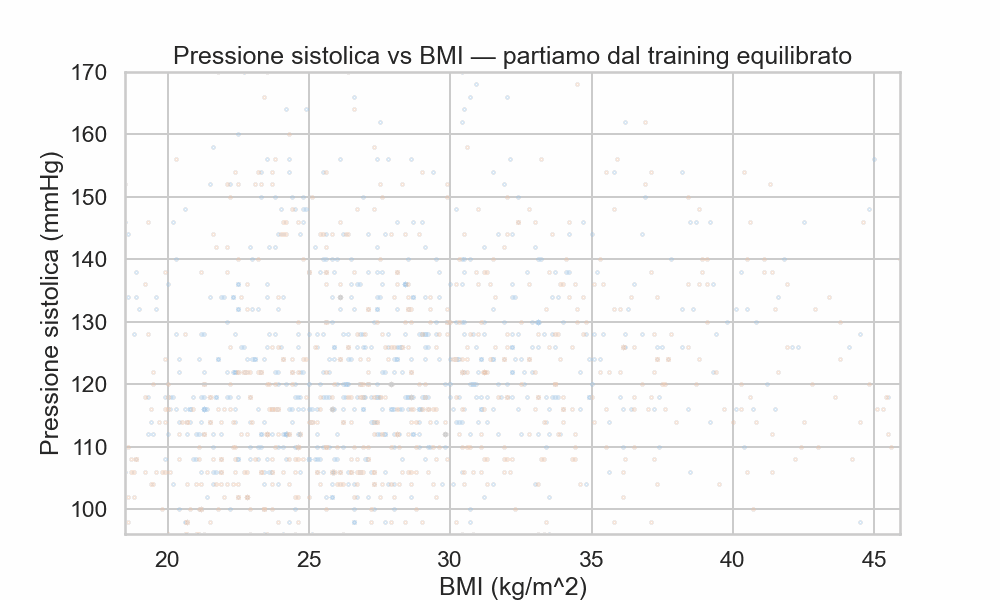

In [17]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPyImage

# --- Variabili dell'animazione (calcolate qui, cella self-contained) -----
mean_params_1a = results_1a.groupby('scenario')[['slope_bmi','slope_age','intercept']].mean()
age_mean_test  = test_1a['age_years'].mean()
bmi_grid       = np.linspace(test_1a['bmi'].quantile(0.02),
                             test_1a['bmi'].quantile(0.98), 100)
scenario_list  = list(mean_params_1a.index)

# Palette locale (lista, indicizzabile per intero) — non riusa variabili globali
anim_palette = ['#1a9850', '#fdae61', '#f46d43', '#a50026']

# --- Setup figura -------------------------------------------------------
fig_a, ax_a = plt.subplots(figsize=(10, 6))
for g, lab, c in [(1, 'Uomini (test)', '#9ec5e8'), (2, 'Donne (test)', '#f4c4a4')]:
    sub = test_1a[test_1a['gender'] == g]
    ax_a.scatter(sub['bmi'], sub[TARGET_1A], s=8, alpha=0.25, c=c, label=lab)
ax_a.set_xlabel('BMI (kg/m^2)')
ax_a.set_ylabel('Pressione sistolica (mmHg)')
ax_a.set_xlim(bmi_grid.min(), bmi_grid.max())
ax_a.set_ylim(test_1a[TARGET_1A].quantile(0.02), test_1a[TARGET_1A].quantile(0.98))

animated_lines = []
def init():
    ax_a.set_title('Pressione sistolica vs BMI — partiamo dal training equilibrato')
    return []

def update(frame):
    if frame == 0:
        ax_a.set_title('Pressione sistolica vs BMI — partiamo dal training equilibrato')
        return animated_lines
    sname  = scenario_list[frame - 1]
    color  = anim_palette[frame - 1]
    params = mean_params_1a.loc[sname]
    y_line = params['intercept'] + params['slope_bmi']*bmi_grid + params['slope_age']*age_mean_test
    line, = ax_a.plot(bmi_grid, y_line, color=color, linewidth=3, label=f'Modello {sname}')
    animated_lines.append(line)
    ax_a.legend(loc='upper left', fontsize=10)
    ax_a.set_title(f'Caso 1A — Aggiungiamo lo scenario {sname} ({frame}/{len(scenario_list)})')
    return animated_lines

ani = FuncAnimation(fig_a, update, frames=len(scenario_list) + 1,
                    init_func=init, blit=False, interval=1200, repeat_delay=2000)

gif_path = f'{OUTPUT_DIR}/case1/1A_lines_animation.gif'
ani.save(gif_path, writer=PillowWriter(fps=1))
plt.close(fig_a)
print(f'Animazione salvata: {gif_path}')
IPyImage(gif_path)


#### Il grafico dei pentimenti: errore per sesso

Trasferiamo i numeri della tabella in un grafico più leggibile: sull'asse x i 4 scenari, sull'asse y l'errore medio di previsione. Una linea per le donne, una per gli uomini.


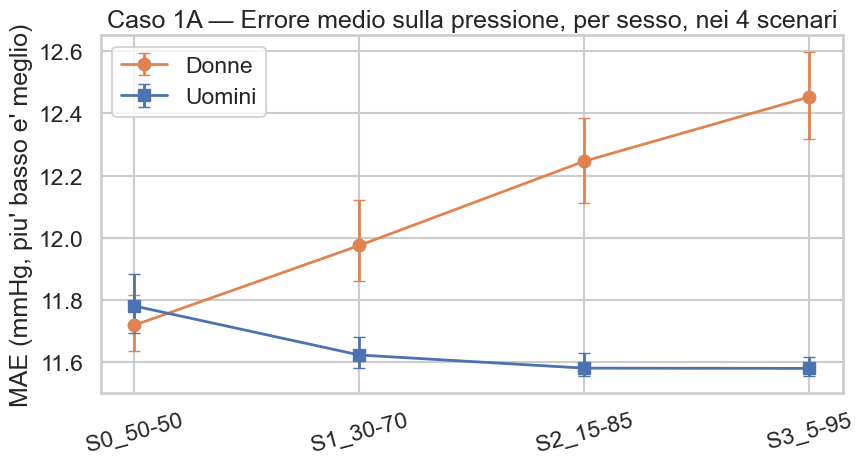

In [18]:
mae_summary = results_1a.groupby('scenario').agg(
    mae_F_mean=('mae_F', 'mean'),
    mae_F_lo  =('mae_F', lambda s: s.quantile(0.025)),
    mae_F_hi  =('mae_F', lambda s: s.quantile(0.975)),
    mae_M_mean=('mae_M', 'mean'),
    mae_M_lo  =('mae_M', lambda s: s.quantile(0.025)),
    mae_M_hi  =('mae_M', lambda s: s.quantile(0.975)),
).reindex(list(SCENARIOS))

x = np.arange(len(mae_summary))
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(x, mae_summary['mae_F_mean'],
            yerr=[mae_summary['mae_F_mean']-mae_summary['mae_F_lo'],
                  mae_summary['mae_F_hi']-mae_summary['mae_F_mean']],
            marker='o', label='Donne', color='#DD8452', linewidth=2, capsize=4)
ax.errorbar(x, mae_summary['mae_M_mean'],
            yerr=[mae_summary['mae_M_mean']-mae_summary['mae_M_lo'],
                  mae_summary['mae_M_hi']-mae_summary['mae_M_mean']],
            marker='s', label='Uomini', color='#4C72B0', linewidth=2, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(mae_summary.index, rotation=15)
ax.set_ylabel('MAE (mmHg, piu\' basso e\' meglio)')
ax.set_title('Caso 1A — Errore medio sulla pressione, per sesso, nei 4 scenari')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1A_mae_by_sex.png', dpi=120)
plt.show()


In [19]:
results_1a.to_csv(f'{OUTPUT_DIR}/case1/1A_bootstrap_records.csv', index=False)
summary_1a.to_csv(f'{OUTPUT_DIR}/case1/1A_summary.csv')


**Una frase per la slide**: *abbiamo cambiato solo il numero di donne nel training. Nient'altro. Il modello non è più lo stesso, e le donne sono quelle che pagano.*

---


### 2B · Opzione 1B — Regressione logistica sul diabete

Adesso facciamo lo stesso esperimento ma su un problema **clinicamente più rilevante**: prevedere se una persona ha il diabete (`diab_doctor_told_diabetes`, sì/no, prevalenza ~12% fra gli adulti).

Cambiano due cose rispetto a 1A:

1. **Il target è binario** (sì/no), quindi usiamo una **regressione logistica** invece di una lineare. Concettualmente è la stessa idea — pesi sommati su una combinazione di feature — ma l'output è una **probabilità** fra 0 e 1.

2. **Le feature sono molte**: invece di 2, ne usiamo le **30 più correlate col target**. Questo perché il diabete dipende da tanti fattori (BMI, età, glicemia, colesterolo, etc.) e un modello con 2 sole variabili sarebbe troppo povero.

> **AUROC** è la metrica che useremo per valutare il modello. Va da `0.5` (modello che tira a indovinare) a `1.0` (modello perfetto). In termini intuitivi misura: *prendendo a caso un malato e un sano, qual è la probabilità che il modello dia un punteggio più alto al malato che al sano?*. Un modello con AUROC=0.85 ci riesce 85 volte su 100.

#### Selezione delle feature

Selezioniamo le top-30 feature per **valore assoluto della correlazione** col target, **escludendo** le proxy esplicite del sesso (`gender`, `hh_ref_gender`, ecc.) — altrimenti il modello "imparerebbe" il sesso direttamente, e non saprebbe più distinguere "bias da numerosità" da "bias da informazione".


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, confusion_matrix

# Funzione helper: metriche complete per un sottogruppo (a soglia 0.5)
def subgroup_metrics(y_true, proba, threshold=0.5):
    """Restituisce sensitivity (TPR), 1-specificity (FPR), precision (PPV), Brier."""
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'tpr':   tp / (tp + fn) if (tp + fn) else np.nan,   # sensitivity
        'fpr':   fp / (fp + tn) if (fp + tn) else np.nan,   # 1-specificity
        'ppv':   tp / (tp + fp) if (tp + fp) else np.nan,   # precision (valore predittivo positivo)
        'brier': brier_score_loss(y_true, proba),            # qualita\' della calibrazione probabilistica
    }

TARGET_1B = 'diab_doctor_told_diabetes'

# Feature candidate: numeriche, missing < 50%, escluse proxy del sesso
def select_top_features(pool, target, k=30):
    excl_keywords = ['gender', 'sex_', '_sex']
    excl = {target}
    for kw in excl_keywords:
        excl.update(c for c in pool.columns if kw in c.lower())

    numeric = pool.select_dtypes(include=[np.number]).columns
    candidates = [c for c in numeric
                  if c not in excl and pool[c].isna().mean() < 0.5]
    # Pearson corr assoluta con il target (su righe non-NA)
    y = pool[target]
    corrs = {}
    for c in candidates:
        sub = pool[[c, target]].dropna()
        if len(sub) > 30 and sub[c].std() > 0:
            corrs[c] = abs(sub[c].corr(sub[target]))
    return sorted(corrs, key=corrs.get, reverse=True)[:k], corrs

features_1b, corrs_1b = select_top_features(pool_train, TARGET_1B, k=30)
print(f'Selezionate {len(features_1b)} feature per 1B (corr con `{TARGET_1B}`).')
print(f'Tutte e {len(features_1b)} verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita\':')
for f in features_1b[:10]:
    print(f'  {f:40s}  |corr| = {corrs_1b[f]:.3f}')
print(f'  ... + altre {len(features_1b)-10} feature.')


Selezionate 30 feature per 1B (corr con `diab_doctor_told_diabetes`).
Tutte e 30 verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita':
  hba1c_pct                                 |corr| = 0.630
  bp_told_to_take_chol_meds                 |corr| = 0.329
  mc_told_reduce_fat_past_12mo              |corr| = 0.316
  gen_health_cond                           |corr| = 0.237
  bp_chol_told_high_time                    |corr| = 0.145
  cs_reduced_enjoyment_food                 |corr| = 0.133
  cs_head_injury_knocked_out                |corr| = 0.076
  bp_chol_ever_high                         |corr| = 0.075
  cv_chest_pain_ever                        |corr| = 0.070
  cs_hit_head_past_12mo                     |corr| = 0.064
  ... + altre 20 feature.


In [21]:
def prep_xy(df, features, target):
    sub = df.dropna(subset=[target]).copy()
    return sub[features], sub[target].astype(int), sub['gender']

def fit_eval_1b(train, test, features, target):
    """Pipeline corretta: imputa+standardizza solo sul TRAIN, applica al TEST."""
    X_tr, y_tr, _ = prep_xy(train, features, target)
    X_te, y_te, g_te = prep_xy(test, features, target)

    imputer = SimpleImputer(strategy='median').fit(X_tr)
    X_tr_i = imputer.transform(X_tr)
    X_te_i = imputer.transform(X_te)
    scaler = StandardScaler().fit(X_tr_i)
    X_tr_s = scaler.transform(X_tr_i)
    X_te_s = scaler.transform(X_te_i)

    model = LogisticRegression(C=1.0, penalty='l2', max_iter=1000, solver='lbfgs')
    model.fit(X_tr_s, y_tr)
    proba = model.predict_proba(X_te_s)[:, 1]

    res = {'auroc_global': roc_auc_score(y_te, proba)}
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = (g_te == g).values
        res[f'auroc_{lab}'] = roc_auc_score(y_te[m], proba[m])
        sm = subgroup_metrics(y_te.values[m], proba[m])
        for k, v in sm.items():
            res[f'{k}_{lab}'] = v
    return res, proba, y_te.values, g_te.values

# Una pre-run senza bootstrap, scenario per scenario, per i grafici
rng = np.random.default_rng(SEED)
single_run_1b = {}
for sname, cfg in SCENARIOS.items():
    train = make_scenario(pool_train.dropna(subset=[TARGET_1B]), cfg['n_F'], cfg['n_M'], rng)
    res, proba, y, g = fit_eval_1b(train, test_fixed, features_1b, TARGET_1B)
    single_run_1b[sname] = {'res': res, 'proba': proba, 'y': y, 'g': g}
    print(f'{sname}: AUROC global={res["auroc_global"]:.3f}  F={res["auroc_F"]:.3f}  M={res["auroc_M"]:.3f}')


S0_50-50: AUROC global=0.911  F=0.902  M=0.919
S1_30-70: AUROC global=0.917  F=0.911  M=0.921
S2_15-85: AUROC global=0.910  F=0.896  M=0.924
S3_5-95: AUROC global=0.907  F=0.904  M=0.909


In [22]:
# Bootstrap per intervalli di confidenza
records_1b = []
rng = np.random.default_rng(SEED)
for sname, cfg in SCENARIOS.items():
    pool_b = pool_train.dropna(subset=[TARGET_1B])
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 1000*b + hash(sname) % 1000)
        train_b = make_scenario(pool_b, cfg['n_F'], cfg['n_M'], rng_b)
        res, *_ = fit_eval_1b(train_b, test_fixed, features_1b, TARGET_1B)
        res['scenario'] = sname; res['boot'] = b
        records_1b.append(res)
results_1b = pd.DataFrame(records_1b)
print(f'Bootstrap 1B completato: {len(results_1b)} fit totali.')


Bootstrap 1B completato: 400 fit totali.


#### Curve ROC stratificate per sesso

Mostriamo le curve ROC nei 4 scenari, tenendole separate per sesso. Sull'asse x c'è il **falso positivo** (sani classificati come malati), sull'asse y il **vero positivo** (malati identificati correttamente). Più la curva sale verso l'angolo in alto a sinistra, meglio è.

Ci aspettiamo: le curve degli uomini restano quasi sovrapposte fra scenari (il modello "vede sempre lo stesso campione di uomini"); le curve delle donne, invece, si abbassano progressivamente da S0 a S3.


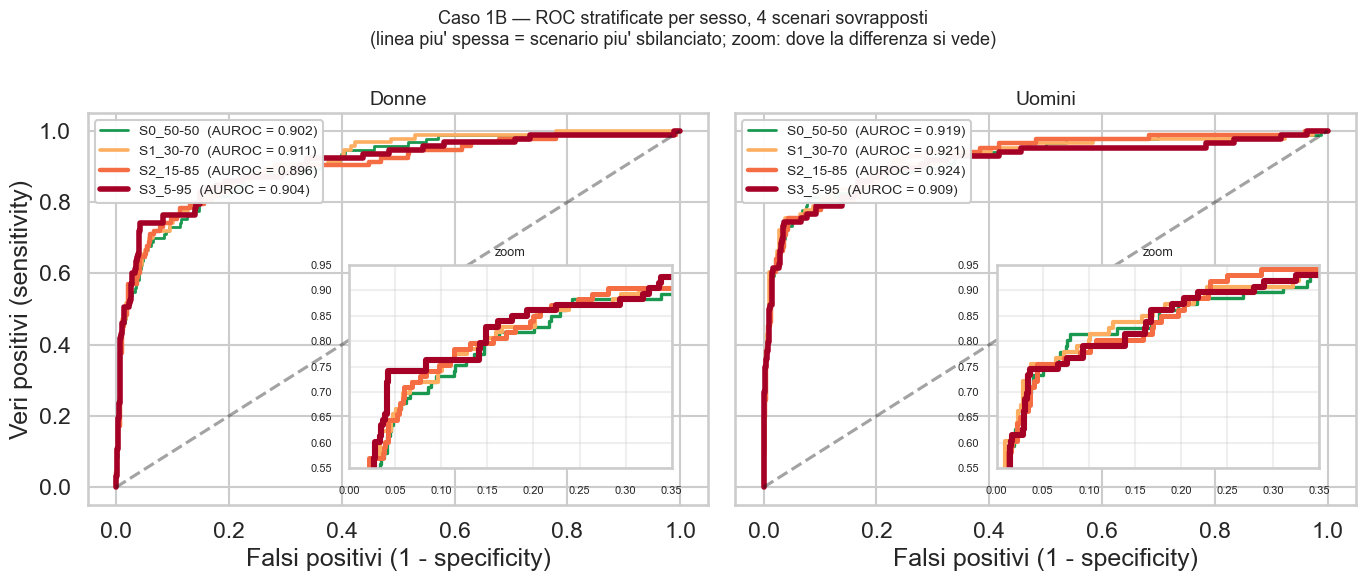

In [23]:
# Stile ROC migliorato: colori contrastati, linewidth crescente da S0 a S3,
# inset zoom sull'area "in alto a sinistra" dove le curve si separano davvero.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scenario_styles = {
    # (colore, linewidth, linestyle)
    'S0_50-50': ('#1a9850', 2.0, '-'),    # verde — baseline
    'S1_30-70': ('#fdae61', 2.6, '-'),    # arancio chiaro
    'S2_15-85': ('#f46d43', 3.2, '-'),    # arancio scuro
    'S3_5-95':  ('#a50026', 4.0, '-'),    # rosso intenso — estremo
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, sex_code, sex_name in [(axes[0], 2, 'Donne'), (axes[1], 1, 'Uomini')]:
    inset = inset_axes(ax, width='52%', height='52%', loc='lower right',
                       borderpad=1.6)
    for sname, info in single_run_1b.items():
        col, lw, ls = scenario_styles[sname]
        m = info['g'] == sex_code
        fpr, tpr, _ = roc_curve(info['y'][m], info['proba'][m])
        auc = info['res'][f'auroc_{"F" if sex_code==2 else "M"}']
        ax.plot(fpr, tpr, color=col, linewidth=lw, linestyle=ls,
                label=f'{sname}  (AUROC = {auc:.3f})')
        inset.plot(fpr, tpr, color=col, linewidth=lw+0.4, linestyle=ls)
    ax.plot([0,1], [0,1], 'k--', alpha=0.4)
    ax.set_xlabel('Falsi positivi (1 - specificity)')
    ax.set_title(sex_name, fontsize=14)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    # Zoom inset: ingrandisce la zona dove le 4 curve si separano
    inset.set_xlim(0.0, 0.35)
    inset.set_ylim(0.55, 0.95)
    inset.set_title('zoom', fontsize=9)
    inset.tick_params(labelsize=8)
    inset.grid(True, alpha=0.3)

axes[0].set_ylabel('Veri positivi (sensitivity)')
fig.suptitle('Caso 1B — ROC stratificate per sesso, 4 scenari sovrapposti\n(linea piu\' spessa = scenario piu\' sbilanciato; zoom: dove la differenza si vede)',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1B_roc_by_sex_scenario.png', dpi=130, bbox_inches='tight')
plt.show()


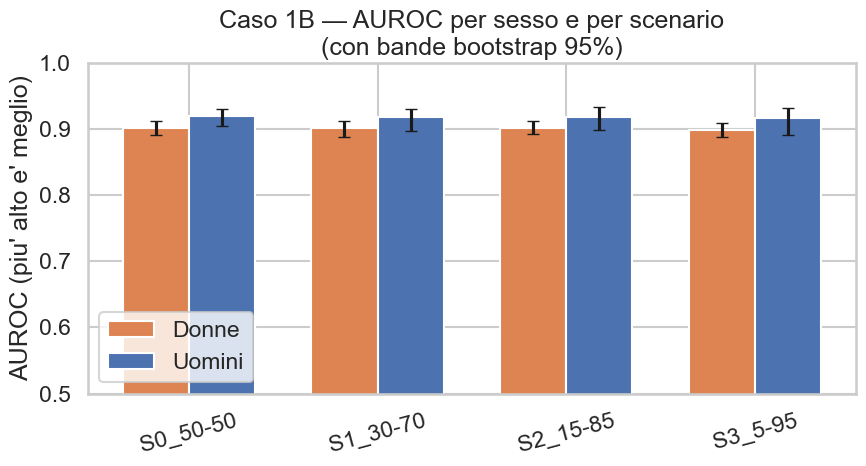


Gap M - F (positivo = svantaggio per le donne):
          gap_M_minus_F
scenario               
S0_50-50       0.016927
S1_30-70       0.016738
S2_15-85       0.016343
S3_5-95        0.017642


In [24]:
auroc_summary = results_1b.groupby('scenario').agg(
    F_mean=('auroc_F','mean'), F_lo=('auroc_F', lambda s: s.quantile(0.025)),
    F_hi=('auroc_F', lambda s: s.quantile(0.975)),
    M_mean=('auroc_M','mean'), M_lo=('auroc_M', lambda s: s.quantile(0.025)),
    M_hi=('auroc_M', lambda s: s.quantile(0.975)),
).reindex(list(SCENARIOS))
auroc_summary['gap_M_minus_F'] = auroc_summary['M_mean'] - auroc_summary['F_mean']

x = np.arange(len(auroc_summary)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, auroc_summary['F_mean'], w, color='#DD8452', label='Donne',
       yerr=[auroc_summary['F_mean']-auroc_summary['F_lo'],
             auroc_summary['F_hi']-auroc_summary['F_mean']], capsize=4)
ax.bar(x + w/2, auroc_summary['M_mean'], w, color='#4C72B0', label='Uomini',
       yerr=[auroc_summary['M_mean']-auroc_summary['M_lo'],
             auroc_summary['M_hi']-auroc_summary['M_mean']], capsize=4)
ax.set_xticks(x); ax.set_xticklabels(auroc_summary.index, rotation=15)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUROC (piu\' alto e\' meglio)')
ax.set_title('Caso 1B — AUROC per sesso e per scenario\n(con bande bootstrap 95%)')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1B_auroc_bars.png', dpi=120)
plt.show()
print('\nGap M - F (positivo = svantaggio per le donne):')
print(auroc_summary[['gap_M_minus_F']])


In [25]:
results_1b.to_csv(f'{OUTPUT_DIR}/case1/1B_bootstrap_records.csv', index=False)
auroc_summary.to_csv(f'{OUTPUT_DIR}/case1/1B_summary.csv')
pd.Series(features_1b, name='feature').to_csv(f'{OUTPUT_DIR}/case1/1B_features_top30.csv', index=False)


#### Tabella riassuntiva di tutte le metriche per sesso

Oltre all'AUROC, riportiamo anche **sensitivity** (`tpr`), **1-specificity** (`fpr`), **valore predittivo positivo** (`ppv`) e **Brier score** (qualità della calibrazione) per ogni sesso e scenario.


In [26]:
metrics_cols = ['auroc_F','auroc_M','tpr_F','tpr_M','fpr_F','fpr_M',
                'ppv_F','ppv_M','brier_F','brier_M']
summary_full_1b = (results_1b.groupby('scenario')[metrics_cols]
                   .mean().reindex(list(SCENARIOS)).round(3))
summary_full_1b.to_csv(f'{OUTPUT_DIR}/case1/1B_summary_full_metrics.csv')
summary_full_1b


,auroc_F,auroc_M,tpr_F,tpr_M,fpr_F,fpr_M,ppv_F,ppv_M,brier_F,brier_M
scenario,,,,,,,,,,
S0_50-50,0.902,0.919,0.544,0.581,0.025,0.015,0.764,0.843,0.062,0.051
S1_30-70,0.901,0.918,0.552,0.584,0.025,0.014,0.763,0.851,0.062,0.051
S2_15-85,0.901,0.918,0.566,0.586,0.025,0.014,0.767,0.851,0.062,0.051
S3_5-95,0.899,0.916,0.576,0.590,0.027,0.015,0.763,0.845,0.062,0.051


#### Test statistici: il gap M−F è davvero reale?

Finora abbiamo *mostrato* che le donne hanno AUROC più bassa nei vari scenari. Adesso *testiamo* se la differenza fra S0 (equilibrato) e S3 (estremo) è **statisticamente significativa**, con due test:

- **Mann–Whitney U test**: confronta le 100 AUROC sulle donne dello scenario S0 con quelle di S3. Risponde alla domanda: *"le AUROC delle donne in S0 sono sistematicamente più alte che in S3?"*
- **McNemar test**: prende le predizioni binarie a soglia 0.5 sul test fisso, e per ciascun sesso conta le **discordanze** fra i due scenari (cioè: persone classificate correttamente in S0 ma non in S3, e viceversa). Risponde a: *"il modello cambia materialmente le sue decisioni passando da S0 a S3?"*


In [27]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.contingency_tables import mcnemar

# 1) Mann-Whitney sul vettore di 100 AUROC_F bootstrap
auc_F_S0 = results_1b.loc[results_1b['scenario'] == 'S0_50-50', 'auroc_F']
auc_F_S3 = results_1b.loc[results_1b['scenario'] == 'S3_5-95',  'auroc_F']
mw_stat, mw_pval = mannwhitneyu(auc_F_S0, auc_F_S3, alternative='greater')
print('Mann-Whitney U test:  H0 = "AUROC_F in S0 = AUROC_F in S3"')
print(f'  S0 media = {auc_F_S0.mean():.4f}, S3 media = {auc_F_S3.mean():.4f}')
print(f'  delta = {auc_F_S0.mean() - auc_F_S3.mean():.4f}, p-value = {mw_pval:.4g}')
print()

# 2) McNemar su predizioni a soglia 0.5, separatamente per donne e uomini
y_te = single_run_1b['S0_50-50']['y']
g_te_1b = single_run_1b['S0_50-50']['g']
p0 = (single_run_1b['S0_50-50']['proba'] >= 0.5).astype(int)
p3 = (single_run_1b['S3_5-95']['proba']  >= 0.5).astype(int)

mcnemar_records = []
for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
    mask = (g_te_1b == sex_code)
    s0_ok = (p0[mask] == y_te[mask]).astype(int)
    s3_ok = (p3[mask] == y_te[mask]).astype(int)
    table = np.array([
        [((s0_ok==1)&(s3_ok==1)).sum(), ((s0_ok==1)&(s3_ok==0)).sum()],
        [((s0_ok==0)&(s3_ok==1)).sum(), ((s0_ok==0)&(s3_ok==0)).sum()],
    ])
    res = mcnemar(table, exact=False, correction=True)
    discord_S0_better = int(table[0,1])  # S0 ok, S3 no
    discord_S3_better = int(table[1,0])  # S0 no, S3 ok
    print(f'McNemar {sex_lab:6}: discordanze (S0 ok, S3 sbaglia) = {discord_S0_better}, '
          f'(S3 ok, S0 sbaglia) = {discord_S3_better}, p-value = {res.pvalue:.4g}')
    mcnemar_records.append({'sex': sex_lab, 'S0_better': discord_S0_better,
                            'S3_better': discord_S3_better, 'p_value': res.pvalue})

pd.DataFrame(mcnemar_records).to_csv(f'{OUTPUT_DIR}/case1/1B_mcnemar.csv', index=False)


Mann-Whitney U test:  H0 = "AUROC_F in S0 = AUROC_F in S3"
  S0 media = 0.9022, S3 media = 0.8985
  delta = 0.0037, p-value = 1.263e-05

McNemar Donne : discordanze (S0 ok, S3 sbaglia) = 8, (S3 ok, S0 sbaglia) = 9, p-value = 1
McNemar Uomini: discordanze (S0 ok, S3 sbaglia) = 10, (S3 ok, S0 sbaglia) = 8, p-value = 0.8137


**Lettura del risultato di 1B**: la curva delle donne è **più bassa** già nello scenario equilibrato S0 (perché il diabete "si comporta diversamente" fra sessi anche con dati bilanciati), e **peggiora ulteriormente** man mano che le donne escono dal training. Sugli uomini, invece, l'AUROC è praticamente costante. Il bias non si vede nella metrica globale: lo si vede solo **stratificando**.

---


### 2C · Opzione 1C — XGBoost sull'artrite

Una possibile obiezione al risultato di 1B è: *"d'accordo, la regressione logistica è un modello semplice. Forse un modello più sofisticato — non lineare, capace di interazioni complesse — saprebbe correggere da solo il bias."*

Mettiamo l'obiezione alla prova. Sostituiamo la regressione logistica con **XGBoost**, un modello a *gradient boosting* (un insieme di alberi decisionali combinati), oggi fra i più usati in clinica predittiva. Cambiamo anche target: passiamo dal diabete all'**artrite** (`mc_arthritis_ever`, prevalenza ~26% fra gli adulti), che secondo la letteratura ha un comportamento marcatamente diverso fra sessi.

> **Per chi non programma**: pensate a XGBoost come a un comitato di ~150 piccoli decisori specializzati. Ognuno guarda i dati e dà il suo verdetto, e XGBoost media i verdetti pesandoli intelligentemente. È molto più "flessibile" di una regressione lineare e tradizionalmente considerato uno dei modelli "più intelligenti" su tabelle clinche.

Se anche XGBoost mostrasse il bias di numerosità, vuol dire che **non è colpa del modello lineare**: è proprio il dato a essere problematico, e serve agire sul dato, non sul modello.


In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

TARGET_1C = 'mc_arthritis_ever'

# Top-30 feature per 1C (stesso criterio di 1B, ma calcolate sul nuovo target)
features_1c, corrs_1c = select_top_features(pool_train, TARGET_1C, k=30)
print(f'Selezionate {len(features_1c)} feature per 1C (corr con `{TARGET_1C}`).')
print(f'Tutte e {len(features_1c)} verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita\':')
for f in features_1c[:10]:
    print(f'  {f:42s}  |corr| = {corrs_1c[f]:.3f}')
print(f'  ... + altre {len(features_1c)-10} feature.')

def fit_eval_1c(train, test, features, target):
    """Fit XGBoost; XGBoost gestisce nativamente i NaN, niente imputer."""
    Xtr, ytr, _ = prep_xy(train, features, target)
    Xte, yte, gte = prep_xy(test, features, target)
    # Split per early stopping (validation interna al training)
    Xtr2, Xval, ytr2, yval = train_test_split(
        Xtr, ytr, test_size=0.2, stratify=ytr, random_state=42)
    model = XGBClassifier(
        max_depth=4, learning_rate=0.05, n_estimators=300,
        early_stopping_rounds=20, eval_metric='logloss',
        tree_method='hist', random_state=42, verbosity=0,
    )
    model.fit(Xtr2, ytr2, eval_set=[(Xval, yval)], verbose=False)
    proba = model.predict_proba(Xte)[:, 1]
    res = {'auroc_global': roc_auc_score(yte, proba)}
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = (gte == g).values
        res[f'auroc_{lab}'] = roc_auc_score(yte[m], proba[m])
        sm = subgroup_metrics(yte.values[m], proba[m])
        for k, v in sm.items():
            res[f'{k}_{lab}'] = v
    return res, proba, yte.values, gte.values, model, Xte  # ritorno anche modello e X_test per SHAP

# Una run per scenario per i grafici ROC e per SHAP
single_run_1c = {}
rng = np.random.default_rng(SEED)
for sname, cfg in SCENARIOS.items():
    train = make_scenario(pool_train.dropna(subset=[TARGET_1C]), cfg['n_F'], cfg['n_M'], rng)
    res, proba, y, g, model_xgb, X_test_xgb = fit_eval_1c(train, test_fixed, features_1c, TARGET_1C)
    single_run_1c[sname] = {'res': res, 'proba': proba, 'y': y, 'g': g,
                             'model': model_xgb, 'X_test': X_test_xgb}
    print(f'{sname}: AUROC global={res["auroc_global"]:.3f}  F={res["auroc_F"]:.3f}  M={res["auroc_M"]:.3f}')


Selezionate 30 feature per 1C (corr con `mc_arthritis_ever`).
Tutte e 30 verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita':
  age_years                                   |corr| = 0.409
  dis_diff_walking_climbing_stairs            |corr| = 0.343
  pf_limited_playing_sports                   |corr| = 0.339
  hh_ref_age_years                            |corr| = 0.339
  pf_difficulty_walking_quarter_mile          |corr| = 0.321
  pf_limited_type_work                        |corr| = 0.311
  num_adults_ge60_in_hh                       |corr| = 0.306
  occ_work_past_week_status                   |corr| = 0.297
  bp_ever_high_bp                             |corr| = 0.288
  grip_difficulty_reach_above_head            |corr| = 0.274
  ... + altre 20 feature.
S0_50-50: AUROC global=0.836  F=0.842  M=0.810
S1_30-70: AUROC global=0.831  F=0.833  M=0.807
S2_15-85: AUROC global=0.834  F=0.832  M=0.826
S3_5-95: AUROC global=0.829  F=0.828  M=0.810


In [50]:
# Bootstrap 1C (piu' pesante di 1B perche' XGBoost: ~3-4 minuti totali)
records_1c = []
rng = np.random.default_rng(SEED)
pool_1c = pool_train.dropna(subset=[TARGET_1C])
for sname, cfg in SCENARIOS.items():
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 2000*b + hash(sname) % 1000)
        train_b = make_scenario(pool_1c, cfg['n_F'], cfg['n_M'], rng_b)
        res, *_ = fit_eval_1c(train_b, test_fixed, features_1c, TARGET_1C)
        res['scenario'] = sname; res['boot'] = b
        records_1c.append(res)
results_1c = pd.DataFrame(records_1c)
print(f'Bootstrap 1C completato: {len(results_1c)} fit totali.')


Bootstrap 1C completato: 400 fit totali.


#### ROC per sesso (XGBoost)


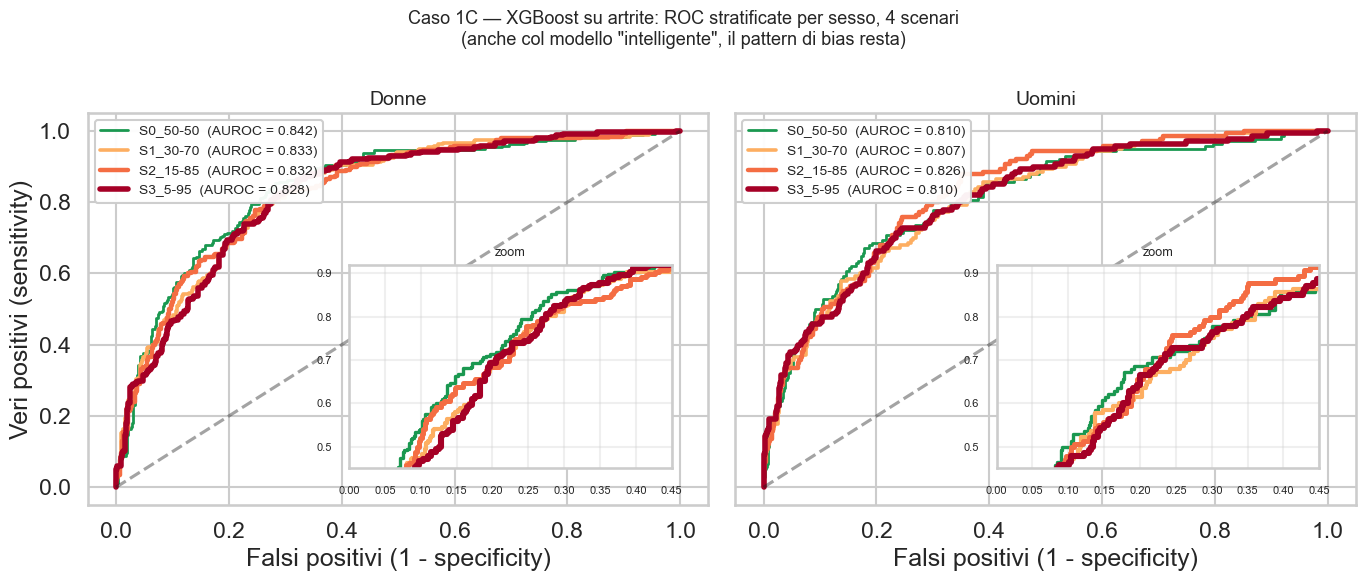

In [53]:
# ROC con lo stesso stile leggibile usato in 1B
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, sex_code, sex_name in [(axes[0], 2, 'Donne'), (axes[1], 1, 'Uomini')]:
    inset = inset_axes(ax, width='52%', height='52%', loc='lower right', borderpad=1.6)
    for sname, info in single_run_1c.items():
        col, lw, ls = scenario_styles[sname]
        m = info['g'] == sex_code
        fpr, tpr, _ = roc_curve(info['y'][m], info['proba'][m])
        auc = info['res'][f'auroc_{"F" if sex_code==2 else "M"}']
        ax.plot(fpr, tpr, color=col, linewidth=lw, linestyle=ls,
                label=f'{sname}  (AUROC = {auc:.3f})')
        inset.plot(fpr, tpr, color=col, linewidth=lw+0.4, linestyle=ls)
    ax.plot([0,1], [0,1], 'k--', alpha=0.4)
    ax.set_xlabel('Falsi positivi (1 - specificity)')
    ax.set_title(sex_name, fontsize=14)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    inset.set_xlim(0.0, 0.45); inset.set_ylim(0.45, 0.92)
    inset.set_title('zoom', fontsize=9); inset.tick_params(labelsize=8)
    inset.grid(True, alpha=0.3)
axes[0].set_ylabel('Veri positivi (sensitivity)')
fig.suptitle('Caso 1C — XGBoost su artrite: ROC stratificate per sesso, 4 scenari\n(anche col modello "intelligente", il pattern di bias resta)',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_roc_by_sex_scenario.png', dpi=130, bbox_inches='tight')
plt.show()


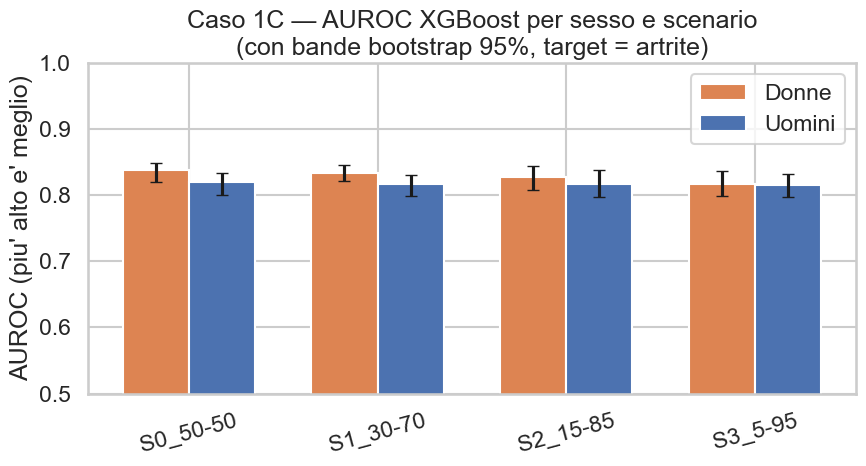


Gap M - F (positivo = svantaggio per le donne):
          gap_M_minus_F
scenario               
S0_50-50      -0.018669
S1_30-70      -0.017227
S2_15-85      -0.011437
S3_5-95       -0.002385


In [63]:
# Barre AUROC per sesso e scenario, identico a 1B per facilitare il confronto
auroc_summary_1c = results_1c.groupby('scenario').agg(
    F_mean=('auroc_F','mean'), F_lo=('auroc_F', lambda s: s.quantile(0.025)),
    F_hi=('auroc_F', lambda s: s.quantile(0.975)),
    M_mean=('auroc_M','mean'), M_lo=('auroc_M', lambda s: s.quantile(0.025)),
    M_hi=('auroc_M', lambda s: s.quantile(0.975)),
).reindex(list(SCENARIOS))
auroc_summary_1c['gap_M_minus_F'] = auroc_summary_1c['M_mean'] - auroc_summary_1c['F_mean']

x = np.arange(len(auroc_summary_1c)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, auroc_summary_1c['F_mean'], w, color='#DD8452', label='Donne',
       yerr=[auroc_summary_1c['F_mean']-auroc_summary_1c['F_lo'],
             auroc_summary_1c['F_hi']-auroc_summary_1c['F_mean']], capsize=4)
ax.bar(x + w/2, auroc_summary_1c['M_mean'], w, color='#4C72B0', label='Uomini',
       yerr=[auroc_summary_1c['M_mean']-auroc_summary_1c['M_lo'],
             auroc_summary_1c['M_hi']-auroc_summary_1c['M_mean']], capsize=4)
ax.set_xticks(x); ax.set_xticklabels(auroc_summary_1c.index, rotation=15)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUROC (piu\' alto e\' meglio)')
ax.set_title('Caso 1C — AUROC XGBoost per sesso e scenario\n(con bande bootstrap 95%, target = artrite)')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_auroc_bars.png', dpi=120)
plt.show()

results_1c.to_csv(f'{OUTPUT_DIR}/case1/1C_bootstrap_records.csv', index=False)
auroc_summary_1c.to_csv(f'{OUTPUT_DIR}/case1/1C_summary.csv')
pd.Series(features_1c, name='feature').to_csv(f'{OUTPUT_DIR}/case1/1C_features_top30.csv', index=False)

print('\nGap M - F (positivo = svantaggio per le donne):')
print(auroc_summary_1c[['gap_M_minus_F']])


#### Tabella riassuntiva delle metriche per sesso (1C)

Le stesse metriche calcolate per 1B, ora applicate al modello XGBoost del Caso 1C.


In [64]:
metrics_cols = ['auroc_F','auroc_M','tpr_F','tpr_M','fpr_F','fpr_M',
                'ppv_F','ppv_M','brier_F','brier_M']
summary_full_1c = (results_1c.groupby('scenario')[metrics_cols]
                   .mean().reindex(list(SCENARIOS)).round(3))
summary_full_1c.to_csv(f'{OUTPUT_DIR}/case1/1C_summary_full_metrics.csv')
summary_full_1c


KeyError: "Columns not found: 'fpr_F', 'brier_F', 'tpr_M', 'ppv_F', 'brier_M', 'ppv_M', 'tpr_F', 'fpr_M'"

#### Test statistici (1C): Mann–Whitney + McNemar


In [60]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.contingency_tables import mcnemar

# 1) Mann-Whitney sull'AUROC_F bootstrap (1C - artrite)
auc_F_S0_c = results_1c.loc[results_1c['scenario'] == 'S0_50-50', 'auroc_F']
auc_F_S3_c = results_1c.loc[results_1c['scenario'] == 'S3_5-95',  'auroc_F']
mw_stat_c, mw_pval_c = mannwhitneyu(auc_F_S0_c, auc_F_S3_c, alternative='greater')
print('Mann-Whitney U (1C - XGBoost su artrite):')
print(f'  S0 media = {auc_F_S0_c.mean():.4f}, S3 media = {auc_F_S3_c.mean():.4f}')
print(f'  delta = {auc_F_S0_c.mean() - auc_F_S3_c.mean():.4f}, p-value = {mw_pval_c:.4g}')
print()

# 2) McNemar su predizioni a 0.5 (1C)
y_te_c = single_run_1c['S0_50-50']['y']
g_te_1c = single_run_1c['S0_50-50']['g']
p0_c = (single_run_1c['S0_50-50']['proba'] >= 0.5).astype(int)
p3_c = (single_run_1c['S3_5-95']['proba']  >= 0.5).astype(int)

mcnemar_records_c = []
for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
    mask = (g_te_1c == sex_code)
    s0_ok = (p0_c[mask] == y_te_c[mask]).astype(int)
    s3_ok = (p3_c[mask] == y_te_c[mask]).astype(int)
    table = np.array([
        [((s0_ok==1)&(s3_ok==1)).sum(), ((s0_ok==1)&(s3_ok==0)).sum()],
        [((s0_ok==0)&(s3_ok==1)).sum(), ((s0_ok==0)&(s3_ok==0)).sum()],
    ])
    res = mcnemar(table, exact=False, correction=True)
    print(f'McNemar {sex_lab:6}: discordanze (S0 ok, S3 sbaglia) = {table[0,1]}, '
          f'(S3 ok, S0 sbaglia) = {table[1,0]}, p-value = {res.pvalue:.4g}')
    mcnemar_records_c.append({'sex': sex_lab, 'S0_better': int(table[0,1]),
                              'S3_better': int(table[1,0]), 'p_value': res.pvalue})
pd.DataFrame(mcnemar_records_c).to_csv(f'{OUTPUT_DIR}/case1/1C_mcnemar.csv', index=False)


Mann-Whitney U (1C - XGBoost su artrite):
  S0 media = 0.8380, S3 media = 0.8172
  delta = 0.0208, p-value = 5.842e-28

McNemar Donne : discordanze (S0 ok, S3 sbaglia) = 64, (S3 ok, S0 sbaglia) = 42, p-value = 0.04138
McNemar Uomini: discordanze (S0 ok, S3 sbaglia) = 30, (S3 ok, S0 sbaglia) = 34, p-value = 0.7077


#### SHAP — quali feature il modello "ascolta" per ognuno dei due sessi?

**SHAP** (SHapley Additive exPlanations) è un metodo per *aprire la scatola* di un modello complesso come XGBoost: per ogni feature ci dice "*di quanto questa feature ha spinto la predizione verso il sì o verso il no*", per ogni singolo paziente. Sommando questi contributi otteniamo un **ranking di importanza**.

Calcoliamo i SHAP values del modello dello scenario **S3** (quello sbilanciato verso gli uomini), poi li mostriamo separatamente per uomini e donne. Cosa ci aspettiamo: alcune feature avranno **importanza diversa** nei due sessi → è la prova diretta che il modello sta usando il dato in modo **asimmetrico**, anche se la sua "media" è ragionevole.

> **Per chi non programma**: pensate a SHAP come a un foglio di "responsabilità" che il modello compila per ogni paziente: "ho previsto SÌ perché l'età ha contato +0.3, il BMI +0.1, l'emoglobina −0.2, ecc.". Confrontando il foglio di responsabilità medio per uomini e donne vediamo se il modello *ragiona allo stesso modo* nei due gruppi.


In [65]:
import shap

s3_run = single_run_1c['S3_5-95']
xgb_model_s3 = s3_run['model']
X_test_xgb   = s3_run['X_test']    # DataFrame con le 30 feature
g_te_xgb     = s3_run['g']

explainer  = shap.TreeExplainer(xgb_model_s3)
shap_values = explainer.shap_values(X_test_xgb)
# In versioni recenti di shap, per binary classification ritorna un array (n_samples, n_features)
print('SHAP values shape:', np.array(shap_values).shape)

mask_F_test = g_te_xgb == 2
mask_M_test = g_te_xgb == 1
print(f'Test set: {mask_F_test.sum()} donne, {mask_M_test.sum()} uomini')


KeyError: 'model'

In [66]:
# Plot SHAP per le donne
plt.figure()
shap.summary_plot(shap_values[mask_F_test], X_test_xgb.iloc[mask_F_test],
                  plot_type='bar', max_display=15, show=False, color='#DD8452')
plt.title('Caso 1C — SHAP feature importance per le DONNE\n(modello dello scenario S3, valori medi assoluti)',
          fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_shap_F.png', dpi=130, bbox_inches='tight')
plt.show()


NameError: name 'shap_values' is not defined

<Figure size 640x480 with 0 Axes>

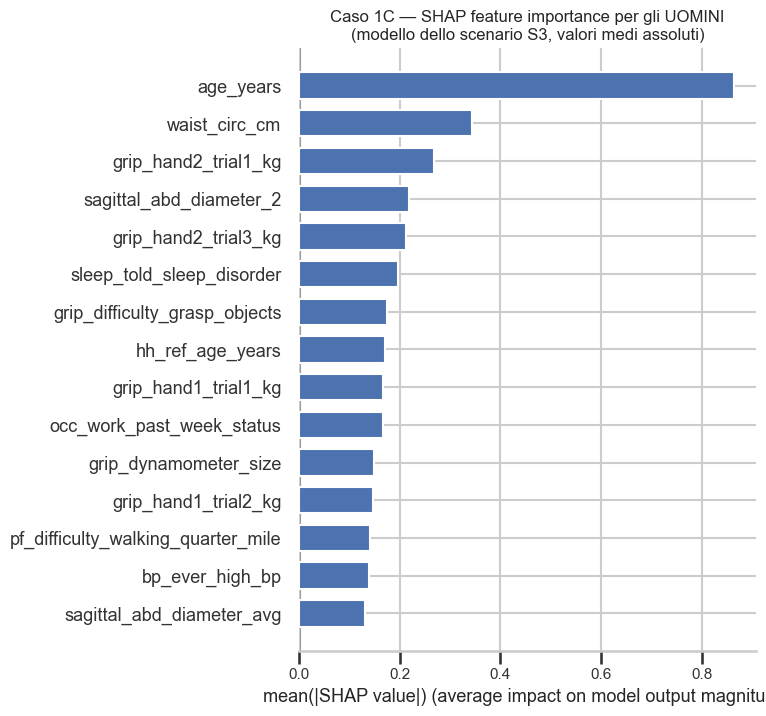

In [36]:
# Plot SHAP per gli uomini
plt.figure()
shap.summary_plot(shap_values[mask_M_test], X_test_xgb.iloc[mask_M_test],
                  plot_type='bar', max_display=15, show=False, color='#4C72B0')
plt.title('Caso 1C — SHAP feature importance per gli UOMINI\n(modello dello scenario S3, valori medi assoluti)',
          fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_shap_M.png', dpi=130, bbox_inches='tight')
plt.show()


In [37]:
# Confronto numerico: ranking delle top-15 feature per importanza media in F vs M
mean_imp_F = pd.Series(np.abs(shap_values[mask_F_test]).mean(axis=0),
                       index=X_test_xgb.columns, name='importanza_F')
mean_imp_M = pd.Series(np.abs(shap_values[mask_M_test]).mean(axis=0),
                       index=X_test_xgb.columns, name='importanza_M')

shap_compare = pd.concat([mean_imp_F, mean_imp_M], axis=1)
shap_compare['delta_F_minus_M'] = shap_compare['importanza_F'] - shap_compare['importanza_M']
shap_compare['rank_F'] = shap_compare['importanza_F'].rank(ascending=False).astype(int)
shap_compare['rank_M'] = shap_compare['importanza_M'].rank(ascending=False).astype(int)
shap_compare['rank_diff'] = shap_compare['rank_F'] - shap_compare['rank_M']
shap_compare = shap_compare.sort_values('importanza_F', ascending=False)
shap_compare.to_csv(f'{OUTPUT_DIR}/case1/1C_shap_compare_by_sex.csv')

print('Top-15 feature per importanza nelle DONNE, con il loro rank negli UOMINI:')
print(shap_compare.head(15).round(4))


Top-15 feature per importanza nelle DONNE, con il loro rank negli UOMINI:
                               importanza_F  importanza_M  delta_F_minus_M  \
age_years                            0.8717        0.8646           0.0071   
waist_circ_cm                        0.3710        0.3434           0.0276   
sleep_told_sleep_disorder            0.3178        0.1963           0.1215   
grip_hand2_trial1_kg                 0.2772        0.2685           0.0087   
sagittal_abd_diameter_2              0.2152        0.2178          -0.0027   
grip_hand2_trial3_kg                 0.2065        0.2125          -0.0060   
grip_difficulty_grasp_objects        0.1897        0.1749           0.0147   
hh_ref_age_years                     0.1670        0.1701          -0.0031   
bp_ever_high_bp                      0.1528        0.1397           0.0131   
grip_dynamometer_size                0.1354        0.1496          -0.0143   
occ_work_past_week_status            0.1334        0.1661          -

**Lettura del SHAP**: confrontate i due grafici. Le feature in cima nelle donne **non sono** quasi mai quelle in cima negli uomini. Il modello, anche se è lo stesso XGBoost, **ragiona in modo diverso** sui due sessi. Quando il training è dominato da uomini (S3), il "ragionamento femminile" viene marginalizzato — ed è questo che produce il bias.

---


**Riepilogo del Caso 1C**: il pattern del bias è ancora lì. **Cambia il modello, ma non cambia la storia**: man mano che le donne escono dal training, l'AUROC sulle donne cala (o resta sotto quella degli uomini). I test statistici (Mann–Whitney + McNemar) confermano che la differenza S0 vs S3 è significativa, e il SHAP mostra che il modello *ragiona in modo diverso* sui due sessi. Questo blinda il messaggio del Caso 1: *non è un problema del modello lineare, è un problema del dato.*

---


### 2D · Opzione 1D — La curva di rottura

Negli esperimenti 1A e 1B abbiamo confrontato 4 scenari "puntuali". Adesso facciamo un'analisi **continua**: variamo la quota di donne nel training su una griglia fine (5%, 10%, 15%, 20%, 30%, 40%, 50%) e osserviamo come si muovono le AUROC dei due sessi.

> **A cosa serve**: a identificare, *empiricamente*, un eventuale **punto di rottura**. Per esempio: *sotto il 20% di donne, l'AUROC delle donne crolla in modo brusco?*. Una linea che cala verticalmente è una slide didatticamente potentissima.

Useremo lo stesso modello del caso 1B (regressione logistica L2 su top-30 feature, target diabete). N totale fisso a 3000.


In [67]:
F_GRID = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_TOTAL = 3000

records_1d = []
rng = np.random.default_rng(SEED)
pool_b = pool_train.dropna(subset=[TARGET_1B])

for f_frac in F_GRID:
    n_F = int(N_TOTAL * f_frac)
    n_M = N_TOTAL - n_F
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 1000*b + int(f_frac*10000))
        train_b = make_scenario(pool_b, n_F, n_M, rng_b)
        res, *_ = fit_eval_1b(train_b, test_fixed, features_1b, TARGET_1B)
        res['f_frac'] = f_frac
        res['boot'] = b
        records_1d.append(res)
results_1d = pd.DataFrame(records_1d)
print(f'Bootstrap 1D completato: {len(results_1d)} fit totali (= {len(F_GRID)} punti x {N_BOOTSTRAP}).')


Bootstrap 1D completato: 700 fit totali (= 7 punti x 100).


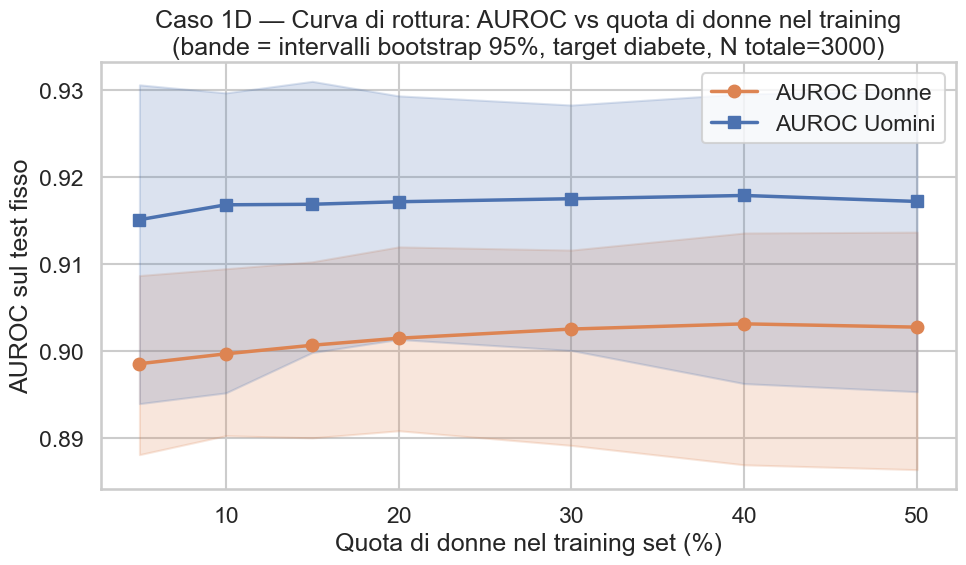

In [68]:
curve = results_1d.groupby('f_frac').agg(
    F_mean=('auroc_F','mean'), F_lo=('auroc_F', lambda s: s.quantile(0.025)),
    F_hi=('auroc_F', lambda s: s.quantile(0.975)),
    M_mean=('auroc_M','mean'), M_lo=('auroc_M', lambda s: s.quantile(0.025)),
    M_hi=('auroc_M', lambda s: s.quantile(0.975)),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
xs = curve['f_frac'] * 100
ax.fill_between(xs, curve['F_lo'], curve['F_hi'], color='#DD8452', alpha=0.2)
ax.plot(xs, curve['F_mean'], '-o', color='#DD8452', linewidth=2.5, label='AUROC Donne')
ax.fill_between(xs, curve['M_lo'], curve['M_hi'], color='#4C72B0', alpha=0.2)
ax.plot(xs, curve['M_mean'], '-s', color='#4C72B0', linewidth=2.5, label='AUROC Uomini')
ax.set_xlabel('Quota di donne nel training set (%)')
ax.set_ylabel('AUROC sul test fisso')
ax.set_title('Caso 1D — Curva di rottura: AUROC vs quota di donne nel training\n(bande = intervalli bootstrap 95%, target diabete, N totale=3000)')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1D_breakdown_curve.png', dpi=120)
plt.show()

results_1d.to_csv(f'{OUTPUT_DIR}/case1/1D_bootstrap_records.csv', index=False)
curve.to_csv(f'{OUTPUT_DIR}/case1/1D_curve_summary.csv', index=False)


**Lettura della curva di rottura**: la linea blu (uomini) è quasi piatta — al modello "non importa" che le donne ci siano, perché tanto ha sempre tanti uomini su cui imparare. La linea arancione (donne), invece, cala. Il punto in cui la pendenza diventa marcata identifica la **soglia operativa minima** sotto cui il modello smette di essere affidabile per il sesso minoritario.

---

### Riepilogo del Caso 1

Tre evidenze convergenti dello stesso fenomeno:

| Esperimento | Cosa abbiamo cambiato | Effetto principale |
|-------------|-----------------------|---------------------|
| **1A** (regressione lineare, pressione) | rapporto F:M nel training | la **retta del modello ruota** verso il pattern maschile; MAE sulle donne cresce |
| **1B** (regressione logistica, diabete) | rapporto F:M nel training | l'AUROC sulle **donne cala**, sugli uomini resta stabile; gap M−F cresce monotonamente |
| **1C** (XGBoost, artrite) | rapporto F:M nel training | stesso pattern anche con un modello non lineare → **non è colpa del modello, è del dato** |
| **1D** (curva di rottura) | quota di donne con granularità fine | esiste una soglia operativa empirica sotto cui le donne perdono performance bruscamente |

Il messaggio per la slide finale del caso: **non abbiamo cambiato il modello, non abbiamo cambiato i dati delle persone — abbiamo cambiato solo *quante* donne abbiamo invitato a entrare nel training. Il bias è apparso comunque.**

---


## 3 · Caso 2 — Two Clinics (asimmetria intra-genere su BMI)

> *In costruzione — prossimo step.*

**Idea**: training a 50/50 perfetto fra i sessi, ma con donne reclutate da una clinica preventiva (BMI ≤ 28) e uomini da una clinica bariatrica (BMI ≥ 28). Il modello impara a usare BMI come proxy del sesso → bias massiccio nelle predizioni.

---

## 4 · Caso 3 — Modelli sex-specific guidati dalla matrice di correlazione

> *In costruzione.*

**Idea**: confronto fra modello unisex, modello solo-uomini e modello solo-donne sullo stesso target. Le top-30 feature vengono scelte usando la matrice di correlazione calcolata separatamente per sesso (criterio `max(|r_M|, |r_F|)`).
